In [13]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib
import os
import ast

PREDICTORS = ["PwmD", "PwmE", "sPwm", "dPwm"]   
TARGET_INT = ["Theta"]  
TARGET = ["DeltaTheta"]
     
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET)   
     
TIME_STEPS = 7
TS = 0.07

In [14]:
TITLES = ["Train_1", "Train_2", "Test_1", "Test_2", "Test_3", "Val", "LSG_1", "LSG_2"]

Datasets = []
NormDatasets = []

# Ler Datasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/Datasets.xlsx", sheet_name=title)
    Datasets.append(df)

# Ler NormDatasets.xlsx
for title in TITLES:
    df = pd.read_excel("./Data/NormDatasets.xlsx", sheet_name=title)
    NormDatasets.append(df)
    
OUT_SCALER = joblib.load("./scalers/out_scaler.pkl")

In [15]:
results = pd.read_excel("resultados.xlsx")
results.head()

,model,Neurons,Ld,Lp,reg,seed,R2_Train_1_Theta,MSE_Train_1_Theta,R2_Train_2_Theta,MSE_Train_2_Theta,R2_Val_Theta,MSE_Val_Theta,R2_Test_1_Theta,MSE_Test_1_Theta,R2_Test_2_Theta,MSE_Test_2_Theta,R2_Test_3_Theta,MSE_Test_3_Theta
0,model_arch16_r0.01_seed8888,[16],0.3,0.7,0.01,8888,0.648529,0.080319,0.811383,0.042764,-3.964400,1.624711,0.668857,0.076169,0.836270,0.038567,-0.843587,0.606240
1,model_arch16_r0.01_seed2348,[16],0.3,0.7,0.01,2348,0.782285,0.049753,0.706355,0.066577,-3.406722,1.442198,0.489531,0.117418,0.884548,0.027195,0.428155,0.188044
2,model_arch16_r0.01_seed4288,[16],0.3,0.7,0.01,4288,0.750937,0.056917,0.453626,0.123877,-1.706963,0.885914,0.581395,0.096287,0.848850,0.035603,0.577463,0.138946
3,model_arch16_r0.01_seed7433,[16],0.3,0.7,0.01,7433,0.721165,0.063720,0.388485,0.138646,-3.861878,1.591158,0.442632,0.128205,0.835090,0.038845,0.591207,0.134426
4,model_arch16_r0.01_seed7583,[16],0.3,0.7,0.01,7583,0.731874,0.061273,0.382453,0.140013,-4.330077,1.744387,0.393957,0.139401,0.858436,0.033345,0.577239,0.139020


In [16]:
def PickModels(df, target, tr1=0.0, tr2=0.0, v1=0.0, t3=0.0):

    r2_tr1 = f"R2_Train_1_{target}"
    r2_tr2 = f"R2_Train_2_{target}"
    r2_val = f"R2_Val_{target}"
    r2_t3 = f"R2_Test_3_{target}"

    # filtro mínimo
    filtered = df[
        (df[r2_tr1] > tr1) &
        (df[r2_tr2] > tr2) &
        (df[r2_t3] > t3) &
        (df[r2_val] > v1)
    ]

    if filtered.empty:
        print("Nenhum modelo satisfaz os critérios.")
        return None

    # 🔹 melhor para cada métrica
    best_tr1 = filtered.sort_values(r2_tr1, ascending=False).iloc[0]
    best_tr2 = filtered.sort_values(r2_tr2, ascending=False).iloc[0]
    best_val = filtered.sort_values(r2_val, ascending=False).iloc[0]
    best_t3 = filtered.sort_values(r2_t3, ascending=False).iloc[0]

    selected = pd.DataFrame([best_tr1, best_tr2, best_val, best_t3]).drop_duplicates()

    cols = ["model", "Neurons", "reg",  r2_tr1, r2_tr2, r2_val, r2_t3]

    table = selected[cols].copy()

    # 🔹 calcular média das métricas
    mean_values = table[[r2_tr1, r2_tr2, r2_val, r2_t3]].mean()

    mean_row = pd.DataFrame([{
        "model": "MEAN",
        "Neurons": "-",
        "reg": "-",
        r2_tr1: mean_values[r2_tr1],
        r2_tr2: mean_values[r2_tr2],
        r2_val: mean_values[r2_val],
        r2_t3: mean_values[r2_t3]
    }])

    table_mean = pd.concat([table, mean_row], ignore_index=True)

    display(table_mean)

    return selected

In [17]:
def BuildModel(architecture, r):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)))
    regularizer =  tf.keras.regularizers.l2(r)
        
    for i, units in enumerate(architecture):

        if i < len(architecture) - 1:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    return_sequences=True,
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
            ))
        else:
            model.add(
                tf.keras.layers.SimpleRNN(
                    units,
                    activation="tanh",
                    kernel_regularizer=regularizer,
                    recurrent_regularizer=regularizer,
                    bias_regularizer=regularizer
                )
            )

    model.add(tf.keras.layers.Dense(OUTPUT_SIZE,
                                    activation='linear',
                                    kernel_regularizer=regularizer,
                                    bias_regularizer=regularizer))

    return model

In [18]:
# def LoadModelFromRow(row):

#     # arquitetura
#     arch = row["Neurons"]
#     if isinstance(arch, str):
#         arch = ast.literal_eval(arch)

#     r = float(row["reg"])
#     model_name = row["model"]

#     weights_path = f"weights/{model_name}.weights.h5"

#     # build
#     model = BuildModel(arch, r)
#     model.build((None, TIME_STEPS, INPUT_SIZE))

#     # load pesos
#     model.load_weights(weights_path)

#     return model

In [19]:
def LoadModelFromRow(row):

    model_name = row["model"]

    model_path = f"models/{model_name}.keras"
    model = tf.keras.saving.load_model(model_path)

    return model

In [20]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)


In [21]:
R = tf.constant(0.0341, dtype=tf.float32)
L = tf.constant(0.0606, dtype=tf.float32)
dt = tf.constant(TS, dtype=tf.float32)

def CinematicModel(Wd, We, theta):

    dtheta_cin = (R / (2 * L)) * (Wd - We)
    # dx_cin = (R / 2) * tf.cos(theta) * (Wd + We)
    # dy_cin = (R / 2) * tf.sin(theta) * (Wd + We)

    # return [dtheta_cin, dx_cin, dy_cin]
    return [dtheta_cin]


def NumericalIntegration(dataset, dq):

    q = [None] * OUTPUT_SIZE

    init_vals = np.array([
        dataset[name].iloc[0] for name in TARGET_INT
    ])

    for j in range(OUTPUT_SIZE):
        q[j] = init_vals[j] + np.cumsum(dq[j] * TS)

    return q

def GetCin(dataset): 
    dq = CinematicModel(tf.convert_to_tensor(dataset["Wd"].values, dtype=tf.float32),
                        tf.convert_to_tensor(dataset["We"].values, dtype=tf.float32), 
                        tf.convert_to_tensor(dataset["Theta"].values, dtype=tf.float32))
    q = NumericalIntegration(dataset, dq)
    return np.vstack(q).T, np.vstack(dq).T

In [22]:
def PlotOut(ax, title, target_name, y_true, y_pred, y_cin):
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    ax.plot(time, y_true, linestyle='-', linewidth=1.5, label='Amostras Reais')
    ax.plot(time, y_pred, linestyle='--', linewidth=1.5, label='Valores preditos')
    ax.plot(time, y_cin, linestyle=':', linewidth=0.5, label='Modelo Cinemático')

    ax.set_title(f'{title} - {target_name}')
    ax.set_xlabel('Tempo [s]')
    ax.set_ylabel(target_name)
    ax.legend()
    ax.grid(True)


def EvalModel(model):
    n_datasets = len(Datasets)
    n_targets = len(TARGET)

    # 🔥 Agora: colunas dobradas (y + dy)
    fig, axs = plt.subplots(
        n_datasets,
        2 * n_targets,
        figsize=(6 * 2 * n_targets, 4 * n_datasets)
    )

    metrics = {
        name: {
            "R2_Train_1": [], "R2_Train_2": [],
            "R2_Val": [],
            "R2_Test_1": [], "R2_Test_2": [], "R2_Test_3": [],
            "R2_LSG_1": [], "R2_LSG_2": [],
            "MSE_Train_1": [], "MSE_Train_2": [],
            "MSE_Val": [],
            "MSE_Test_1": [], "MSE_Test_2": [], "MSE_Test_3": [],
            "MSE_LSG_1": [], "MSE_LSG_2": [],
        }
        for name in TARGET_INT
    }

    for i, NormDataset in enumerate(NormDatasets):

        x = NormDataset[PREDICTORS]
        y = Datasets[i][TARGET_INT]
        dy = Datasets[i][TARGET]

        x, y = CreateSequences(x, y, TIME_STEPS)

        # predição (dy normalizado)
        pred = model(tf.convert_to_tensor(x, dtype=tf.float32)).numpy()

        # desnormalizar
        dy_pred = OUT_SCALER.inverse_transform(pred)

        # cinemático
        y_cin, dy_cin = GetCin(Datasets[i])

        # alinhar tamanhos
        y_true = y
        dy_true = dy.iloc[TIME_STEPS:].values

        y_cin = y_cin[:y_true.shape[0]]
        dy_cin = dy_cin[:dy_true.shape[0]]

        # reconstrução de y
        y_pred = np.zeros_like(dy_pred)

        init_vals = np.array([
            Datasets[i][name].iloc[0] for name in TARGET_INT
        ])

        for j in range(n_targets):
            y_pred[:, j] = init_vals[j] + np.cumsum(dy_pred[:, j] * TS)

        # =========================
        # MÉTRICAS + PLOTS
        # =========================
        for j, name in enumerate(TARGET_INT):

            # métricas (posição)
            r2 = r2_score(y_true[:, j], y_pred[:, j])
            mse = mean_squared_error(y_true[:, j], y_pred[:, j])

            metrics[name][f"R2_{TITLES[i]}"].append(r2)
            metrics[name][f"MSE_{TITLES[i]}"].append(mse)

            print(f"{name} | {TITLES[i]} -> R² = {r2:.4f}, MSE = {mse:.4e}")

            # 🔹 coluna da posição (y)
            ax_y = axs[i, j] if n_datasets > 1 else axs[j]
            PlotOut(
                ax_y,
                TITLES[i],
                f"{name}",
                y_true[:, j],
                y_pred[:, j],
                y_cin[:, j]
            )

            # 🔹 coluna da derivada (dy)
            ax_dy = axs[i, j + n_targets] if n_datasets > 1 else axs[j + n_targets]
            PlotOut(
                ax_dy,
                TITLES[i],
                f"d{name}",
                dy_true[:, j],
                dy_pred[:, j],
                dy_cin[:, j]
            )

    plt.tight_layout()
    return metrics

In [23]:
rows = PickModels(results, "Theta", tr1=0, tr2=0, v1=0.5, t3=0.5)

,model,Neurons,reg,R2_Train_1_Theta,R2_Train_2_Theta,R2_Val_Theta,R2_Test_3_Theta
0,model_arch32-16-8_r0.01_seed7583,"[32, 16, 8]",0.01,0.825049,0.773517,0.577933,0.557566
1,model_arch16-8-4_r0.9_seed2348,"[16, 8, 4]",0.9,0.719517,0.513882,0.803589,0.760699
2,MEAN,-,-,0.772283,0.643700,0.690761,0.659132


Theta | Train_1 -> R² = 0.7873, MSE = 4.8598e-02
Theta | Train_2 -> R² = 0.6376, MSE = 8.2165e-02
Theta | Test_1 -> R² = 0.6065, MSE = 9.0514e-02
Theta | Test_2 -> R² = 0.8673, MSE = 3.1248e-02
Theta | Test_3 -> R² = 0.6164, MSE = 1.2615e-01
Theta | Val -> R² = -3.1347, MSE = 1.3532e+00
Theta | LSG_1 -> R² = 0.2326, MSE = 3.1521e-01
Theta | LSG_2 -> R² = -2.4483, MSE = 1.1818e+00


model                model_arch32-16-8_r0.01_seed7583
Neurons                                   [32, 16, 8]
Ld                                                0.3
Lp                                                0.7
reg                                              0.01
seed                                             7583
R2_Train_1_Theta                             0.825049
MSE_Train_1_Theta                             0.03998
R2_Train_2_Theta                             0.773517
MSE_Train_2_Theta                            0.051349
R2_Val_Theta                                 0.577933
MSE_Val_Theta                                0.138131
R2_Test_1_Theta                              0.831846
MSE_Test_1_Theta                             0.038679
R2_Test_2_Theta                              0.663617
MSE_Test_2_Theta                             0.079235
R2_Test_3_Theta                              0.557566
MSE_Test_3_Theta                             0.145489
Name: 244, dtype: object

Theta | Train_1 -> R² = 0.6558, MSE = 7.8663e-02
Theta | Train_2 -> R² = 0.1440, MSE = 1.9409e-01
Theta | Test_1 -> R² = 0.5784, MSE = 9.6971e-02
Theta | Test_2 -> R² = 0.6575, MSE = 8.0683e-02
Theta | Test_3 -> R² = 0.6261, MSE = 1.2294e-01
Theta | Val -> R² = -1.3426, MSE = 7.6667e-01
Theta | LSG_1 -> R² = 0.1005, MSE = 3.6949e-01
Theta | LSG_2 -> R² = -1.7721, MSE = 9.5007e-01


model                model_arch16-8-4_r0.9_seed2348
Neurons                                  [16, 8, 4]
Ld                                              0.3
Lp                                              0.7
reg                                             0.9
seed                                           2348
R2_Train_1_Theta                           0.719517
MSE_Train_1_Theta                          0.064097
R2_Train_2_Theta                           0.513882
MSE_Train_2_Theta                          0.110215
R2_Val_Theta                               0.803589
MSE_Val_Theta                               0.06428
R2_Test_1_Theta                            0.873845
MSE_Test_1_Theta                           0.029018
R2_Test_2_Theta                            0.745338
MSE_Test_2_Theta                           0.059986
R2_Test_3_Theta                            0.760699
MSE_Test_3_Theta                           0.078691
Name: 226, dtype: object

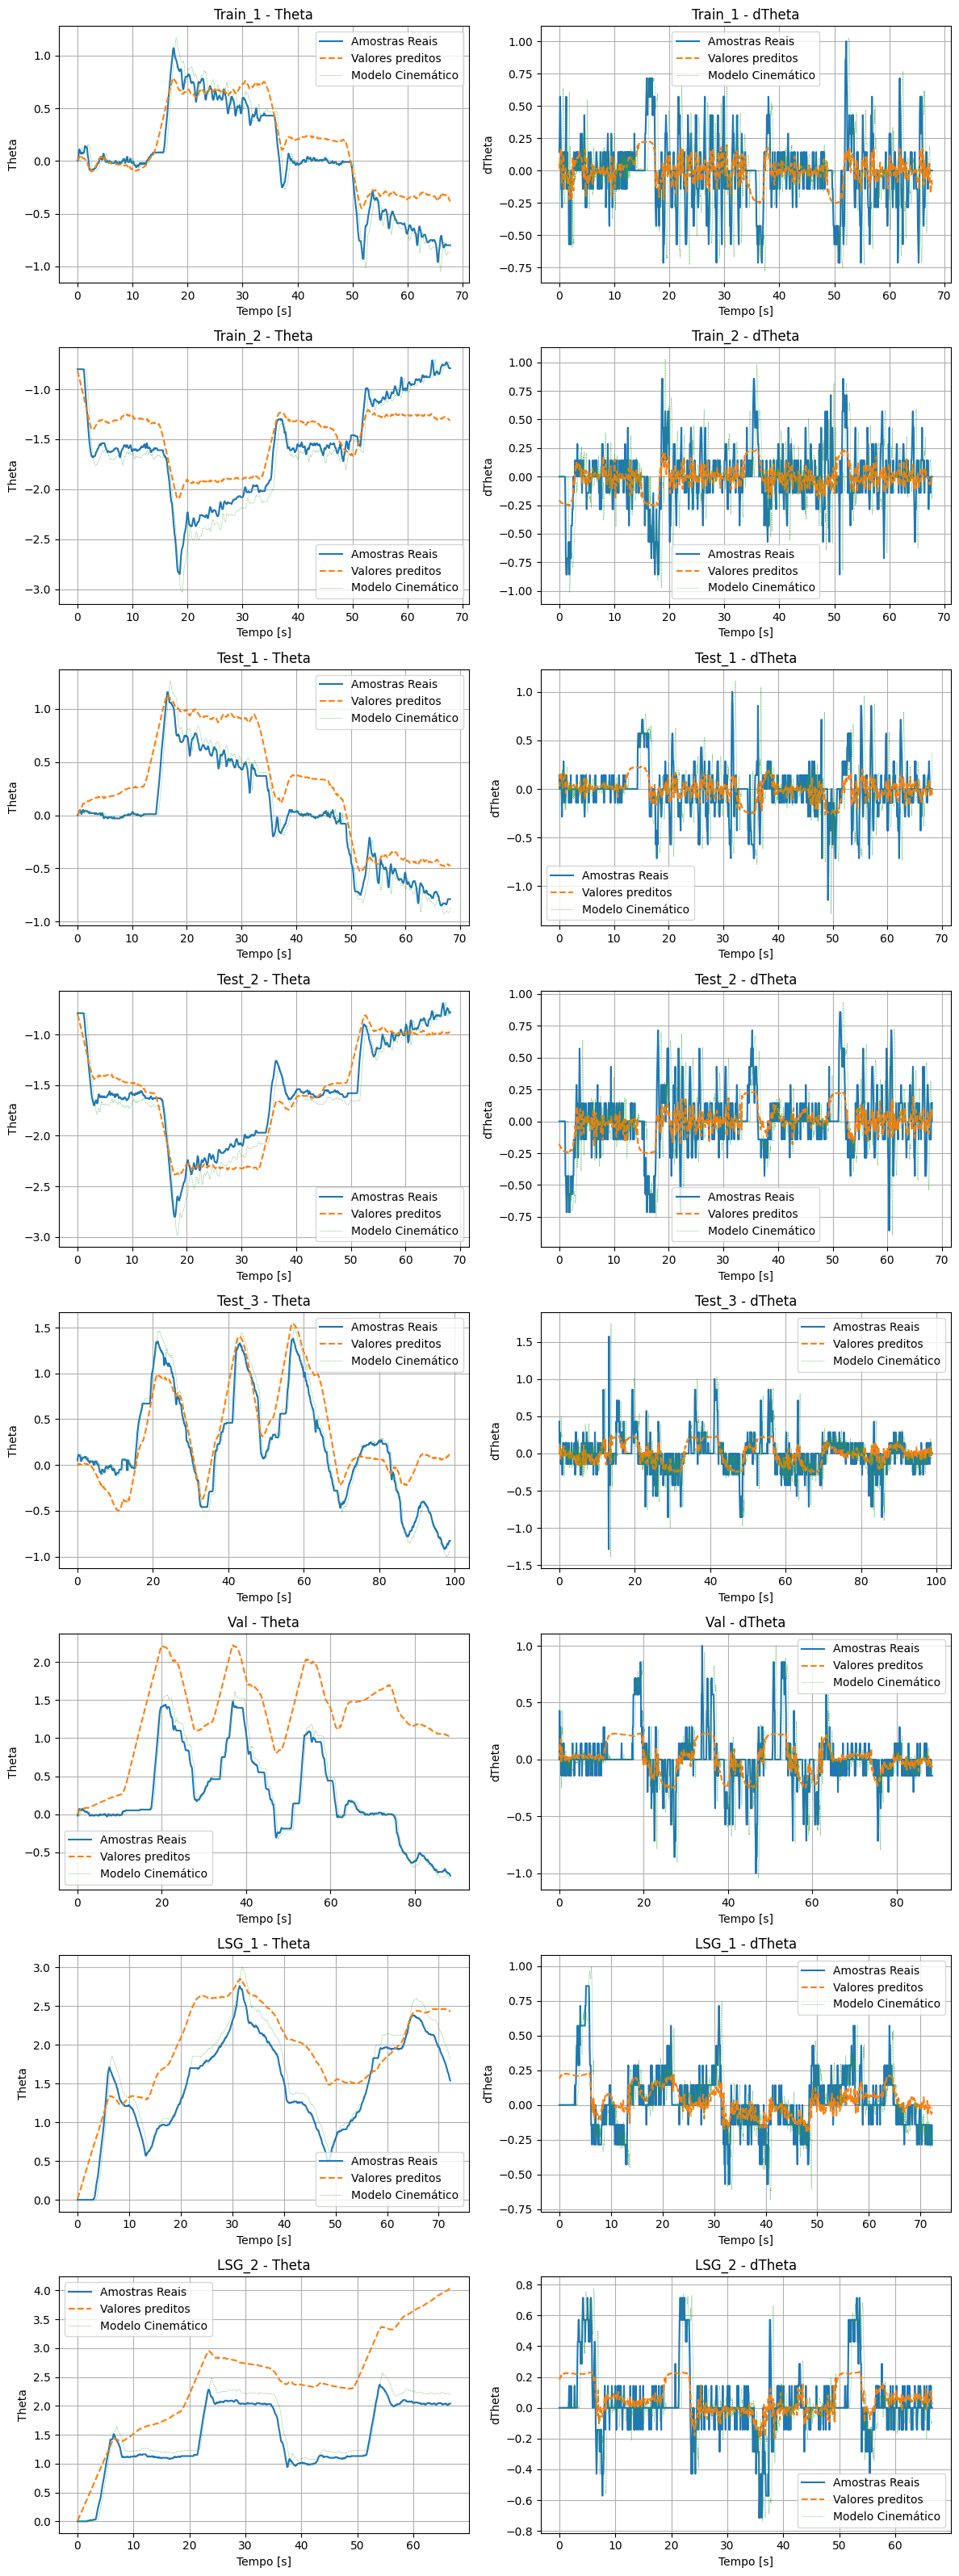

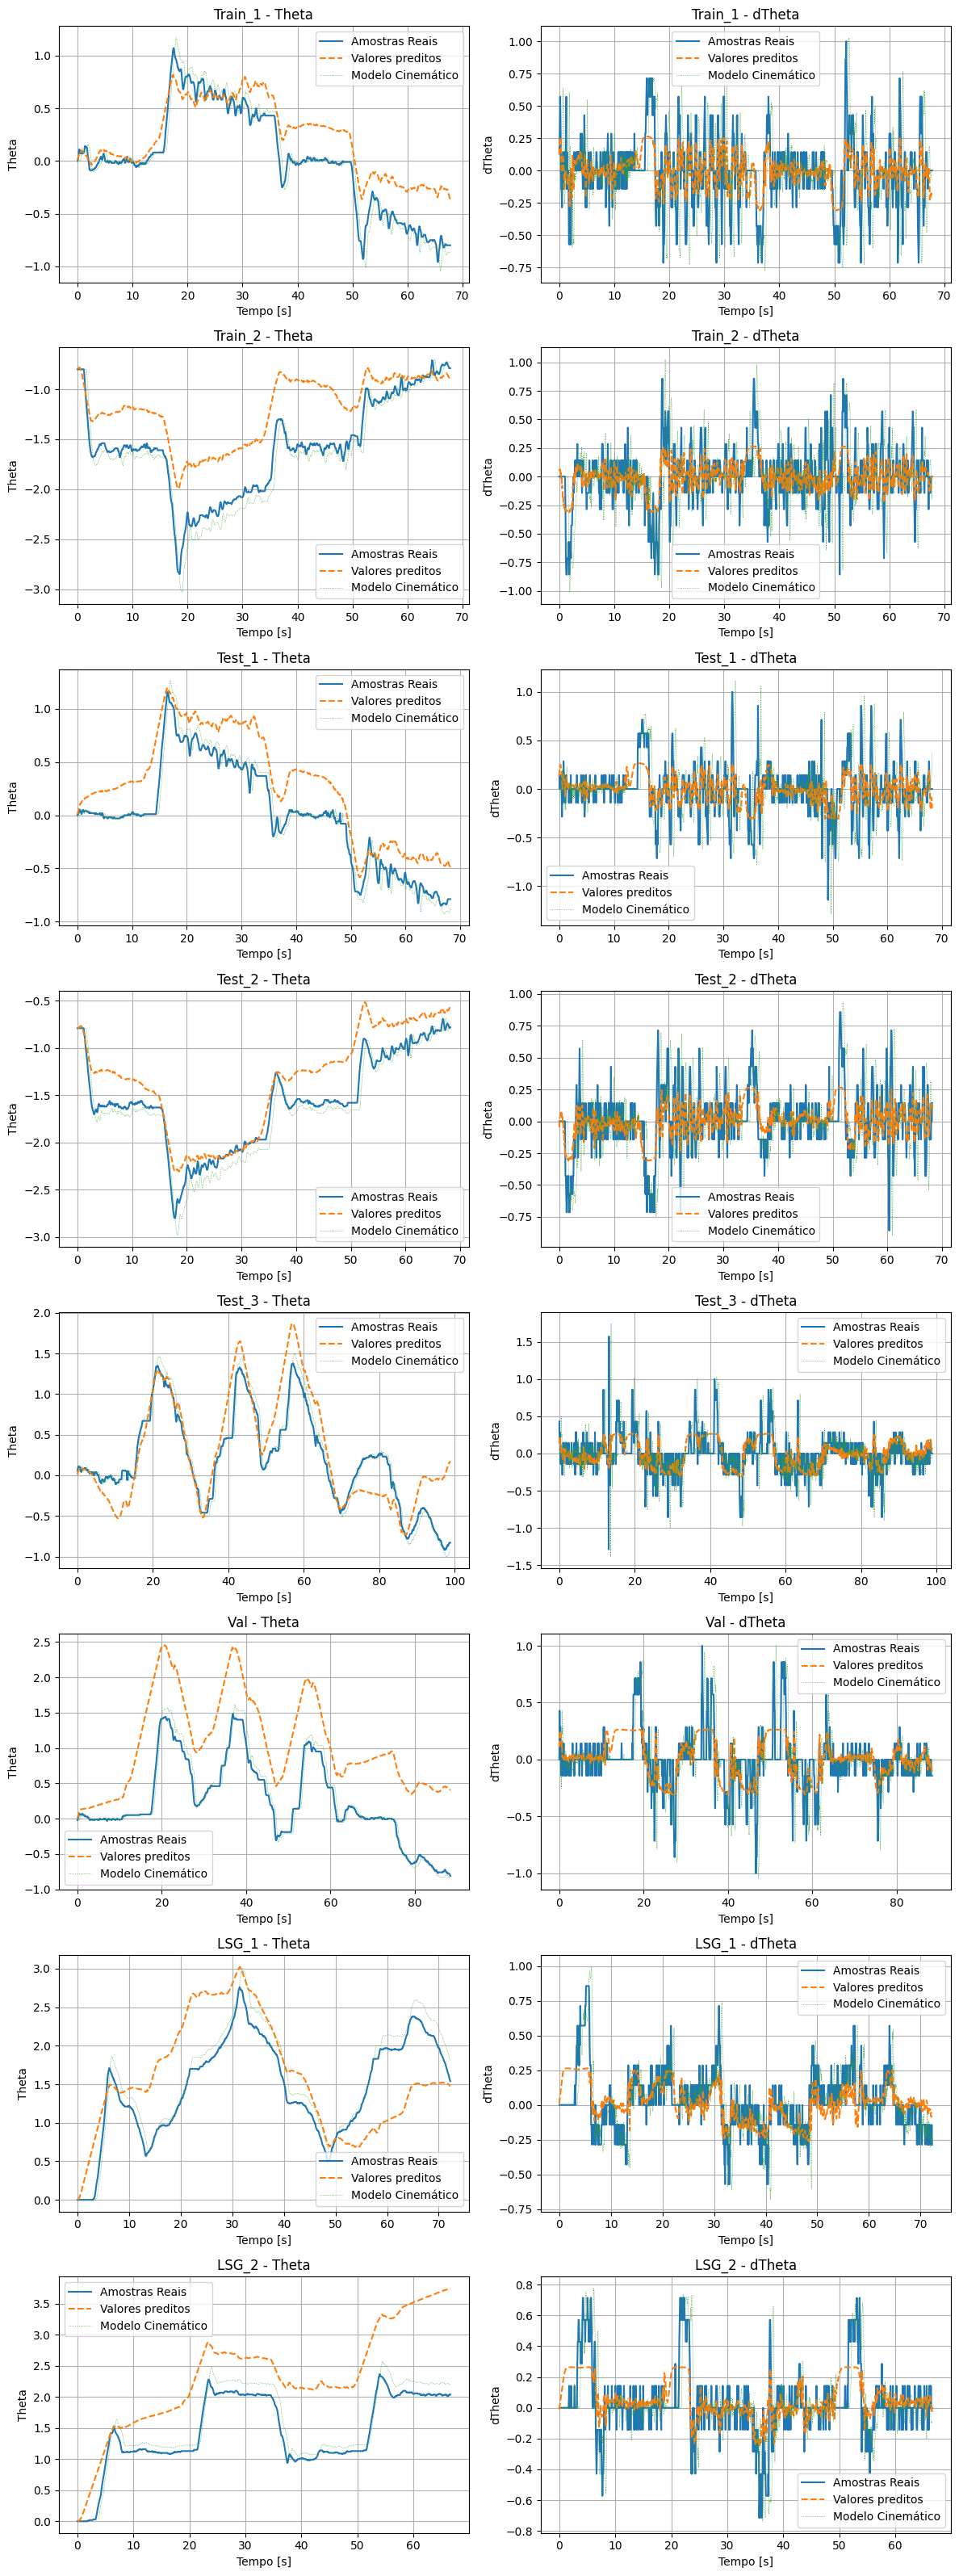

In [24]:
for i in range(len(rows)):
    row = rows.iloc[i]
    model = LoadModelFromRow(row)
    metrics = EvalModel(model)
    display(row)